# Project Overview: Telco Customer Churn
---

**Group Alpha:**
- Amira Aqila Afdhal
- Christian
- Ditya Ayu Anjani

---

# Problem Understanding
---

## Problem Statement
| No | Problem Statement |
|----|-------------------|
| 1 | Can we predict whether a customer will churn based on data set? |
| 2 | How can we improve the product to keep our customers loyal? |
| 3 | How can we improve the product to keep our customers loyal? |

## Stakeholder
| Stakeholder | Description |
|-----|-----|
| Customer Retention Team |  Uses churn prediction to create targeted retention strategies. |

## Goals

| No | Goals |
|----|-------------------|
| 1 | Predict Churn: Build a machine learning model to accurately classify customers likely to churn. |
| 2 | Identify Churn Drivers: Understand which features (e.g., contract type, internet service, payment method) most influence churn. |
| 3 | Customer Segmentation: Group customers based on similar usage patterns and risk levels. |
| 4 | Optimize Retention Efforts: Enable targeted campaigns with data-driven interventions. |

## Evaluation Metic
Target variable:

`1` = Customer `churn` (discontinues subscription)

`0` = Customer `stay`

**Confusion Matrix**
|                             | Prediction: Customer churns (1) | Prediksi: Customer stays (0) |
|-----------------------------|---------------------|----------------------------|
| **Actual: Customer churns (1)**       | True Positive (TP)  | False Negative (FN)        |
| **Actual: Customer stays (0)** | False Positive (FP) | True Negative (TN)         |


- **True Positive (TP)**: Customer actually churns and the model correctly predicts churn
- **False Positive (FP)**: Customer does not churn, but the model predicts churn → might trigger unnecessary retention efforts.
- **False Negative (FN)**: Customer actually churns, but the model predicts no churn → risk of unexpected revenue loss.
- **True Negative (TN)**: Customer does not churn and the model correctly predicts no churn.

### Main focus: Minimize False Negatives (FN)
Since missing actual churners can lead to revenue loss and lower retention rate

Key metrics:
- **Recall**: Measures how many churners are correctly identified by the model.  
  **Recall = $ \frac{TP}{TP + FN} $**
- **ROC AUC (Receiver Operating Characteristic - Area Under Curve)**: Evaluates the model's ability to distinguish churn vs no churn. A higher AUC indicates better discrimination between classes.

- **F<sub>β</sub> Score**: A weighted harmonic mean of precision and recall, where β determines the importance of recall relative to precision.  
  - Commonly used to emphasize recall in churn prediction scenarios.
  - **F<sub>1</sub> Score** (β=1) balances precision and recall equally.
  - **F<sub>2</sub> Score** (β=2) puts more emphasis on recall.


---

# Import Libraries
---

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")
# pd.set_option("display.max_columns", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 500)
pd.set_option("display.max_colwidth", 200)
from scipy.stats import normaltest
from scipy import stats

# Preprocessing
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
import category_encoders as ce
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectPercentile

# Imbalance Dataset
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# Modeling
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
)
import xgboost as xgb
from xgboost import XGBClassifier
import lightgbm as lgb

# Evaluation
from sklearn.model_selection import (
    cross_validate,
    GridSearchCV,
    StratifiedKFold,
    train_test_split,
    cross_val_score,
)
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import (
    make_scorer,
    fbeta_score,
    recall_score,
    precision_score,
    balanced_accuracy_score,
)
from sklearn.metrics import roc_auc_score, RocCurveDisplay

import pickle

---

# Data Understanding
Data source: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

---

## Read Data Set

<div class="alert alert-info" role="alert">Read the main dataset that was provided at the beginning of the final project.</div>

In [17]:
base = pd.read_csv("dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv")
base

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


<div class="alert alert-info" role="alert">Read the status dataset that was found on the internet.</div>

In [19]:
status = pd.read_csv("dataset/Tambahan/Telco_customer_churn_status.csv", sep=";")
status = status[["Customer ID", "Satisfaction Score", "CLTV", "Churn Reason"]]
status

,Customer ID,Satisfaction Score,CLTV,Churn Reason
0,8779-QRDMV,3,5433,Competitor offered more data
1,7495-OOKFY,3,5302,Competitor made better offer
2,1658-BYGOY,2,3179,Competitor made better offer
3,4598-XLKNJ,2,5337,Limited range of services
4,4846-WHAFZ,2,2793,Extra data charges
...,...,...,...,...
7038,2569-WGERO,5,5306,NaN
7039,6840-RESVB,3,2140,NaN
7040,2234-XADUH,4,5560,NaN
7041,4801-JZAZL,4,2793,NaN


<div class="alert alert-info" role="alert">Read the demographics dataset that was found on the internet.</div>

In [21]:
demographic = pd.read_csv(
    "dataset/Tambahan/Telco_customer_churn_demographics.csv", sep=";"
)
demographic = demographic[["Customer ID", "Under 30"]]
demographic

,Customer ID,Under 30
0,8779-QRDMV,No
1,7495-OOKFY,No
2,1658-BYGOY,No
3,4598-XLKNJ,No
4,4846-WHAFZ,No
...,...,...
7038,2569-WGERO,No
7039,6840-RESVB,No
7040,2234-XADUH,No
7041,4801-JZAZL,No


<div class="alert alert-info" role="alert">Merge all the prepared datasets.</div>

In [23]:
# Join all table
df = base.merge(status, left_on="customerID", right_on="Customer ID", how="left").merge(
    demographic, left_on="customerID", right_on="Customer ID", how="left"
)

df = df[
    [
        "customerID",
        "gender",
        "Under 30",
        "SeniorCitizen",
        "Partner",
        "PhoneService",
        "MultipleLines",
        "InternetService",
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies",
        "Contract",
        "PaperlessBilling",
        "PaymentMethod",
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "CLTV",
        "Satisfaction Score",
        "Churn Reason",
        "Churn",
    ]
]

df.sample(5)

,customerID,gender,Under 30,SeniorCitizen,Partner,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,tenure,MonthlyCharges,TotalCharges,CLTV,Satisfaction Score,Churn Reason,Churn
3953,4505-EXZHB,Female,No,1,No,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Electronic check,6,74.40,434.1,3964,1,Competitor offered more data,Yes
4209,4385-ZKVNW,Male,No,0,Yes,Yes,No,DSL,No,Yes,No,Yes,No,No,Month-to-month,Yes,Bank transfer (automatic),44,54.90,2549.1,4412,4,NaN,No
1424,7560-QRBXH,Female,No,0,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,48,19.95,936.7,3396,3,NaN,No
2571,8216-AZUUZ,Female,No,0,Yes,Yes,No,Fiber optic,No,No,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,42,100.40,4303.65,3265,5,NaN,No
1922,8201-AAXCB,Male,No,0,Yes,Yes,Yes,DSL,No,No,No,No,Yes,No,Month-to-month,No,Electronic check,25,60.35,1404.65,3192,4,NaN,No


### Feature Information

| Feature Name        | Description |
|---------------------|-------------|
| customerID          | Unique identifier for each customer |
| gender              | Customer"s gender |
| Under 30            | Whether the customer is under 30 years old |
| SeniorCitizen       | Whether the customer is a senior citizen (1 = Yes, 0 = No) |
| Partner             | Whether the customer has a partner |
| PhoneService        | Whether the customer has phone service |
| MultipleLines       | Whether the customer has multiple phone lines |
| InternetService     | Type of internet service (DSL, Fiber optic, None) |
| OnlineSecurity      | Whether the customer has online security service |
| OnlineBackup        | Whether the customer has online backup service |
| DeviceProtection    | Whether the customer has device protection service |
| TechSupport         | Whether the customer has tech support service |
| StreamingTV         | Whether the customer has streaming TV service |
| StreamingMovies     | Whether the customer has streaming movie service |
| Contract            | Customer"s contract type (Month-to-month, One year, Two year) |
| PaperlessBilling    | Whether the customer is on paperless billing |
| PaymentMethod       | Customer"s payment method (e.g., Electronic check, Mailed check) |
| tenure              | Number of months the customer has stayed with the company |
| MonthlyCharges      | The amount charged to the customer monthly |
| TotalCharges        | The total amount charged to the customer |
| CLTV                | Customer Lifetime Value |
| Satisfaction Score  | Customer satisfaction rating |
| Churn Reason        | Reason the customer churned |
| Churn               | Whether the customer churned (Yes or No) |

### Feature Grouping

| Customer Profile | Service Subscription | Account & Billing | Customer Value & Satisfaction | Churn Outcome |
|--------------|--------------|--------------|--------------|--------------|
| customerID | PhoneService | Contract | CLTV | Churn |
| gender | MultipleLines | PaperlessBilling | Population | Churn Reason |
| Under 30 | InternetService | PaymentMethod |  |  |
| SeniorCitizen | OnlineSecurity | MonthlyCharges |  |  |
| Partner | OnlineBackup | TotalCharges |  |  |
|  | DeviceProtection | Tenure |  |  |
|  | TechSupport |  |  |  |
|  | StreamingTv |  |  |  |
|  | StreamingMovies |  |  |  |

#### Numerical Features
Numerical Features
The following features are numeric and can be used in statistical analysis and modeling:

- `SeniorCitizen`  
- `tenure`  
- `MonthlyCharges`
- `CLTV`  
- `Satisfaction Score`

#### Categorical Features
These features are categorical, representing labels or categories (including binary yes/no and multi-class):

- `customerID`
- `gender`
- `Under 30`
- `Partner`
- `PhoneService`
- `MultipleLines`
- `InternetService`
- `OnlineSecurity`
- `OnlineBackup`
- `DeviceProtection`
- `TechSupport`
- `StreamingTV`
- `StreamingMovies`
- `Contract`
- `PaperlessBilling`
- `PaymentMethod`
- `TotalCharges` *(currently detected as categorical, should be converted to numeric)*
- `Churn Reason`

#### Target Variable
- `Churn` — Indicates whether the customer has churned (`Yes` or `No`)

---

## Data Profiling

<div class="alert alert-info" role="alert">Create a DataFrame to check for missing values, outliers, invalid entries, or incorrect data types.</div>

In [33]:
df_unique = pd.DataFrame(
    {
        "Features": df.columns.values,
        "Data Type": df.dtypes.values,
        "Data Count": df.count().values,
        "Null Value Count": df.isnull().sum().values,
        "Number of Unique Value": df.nunique().values,
        "Unique Value": [df[col].unique() for col in df.columns],
    }
)


print("Unique Table:")
display(df_unique)

# dataframe information
print(f"Total Rows           :", df.shape[0])
print(f"Total Columns        :", df.shape[1])

print("-----------------------------\nData Types Count     :")
print(df.dtypes.value_counts())

Unique Table:


,Features,Data Type,Data Count,Null Value Count,Number of Unique Value,Unique Value
0,customerID,object,7043,0,7043,"[7590-VHVEG, 5575-GNVDE, 3668-QPYBK, 7795-CFOCW, 9237-HQITU, 9305-CDSKC, 1452-KIOVK, 6713-OKOMC, 7892-POOKP, 6388-TABGU, 9763-GRSKD, 7469-LKBCI, 8091-TTVAX, 0280-XJGEX, 5129-JLPIS, 3655-SNQYZ, 819..."
1,gender,object,7043,0,2,"[Female, Male]"
2,Under 30,object,7043,0,2,"[No, Yes]"
3,SeniorCitizen,int64,7043,0,2,"[0, 1]"
4,Partner,object,7043,0,2,"[Yes, No]"
5,PhoneService,object,7043,0,2,"[No, Yes]"
6,MultipleLines,object,7043,0,3,"[No phone service, No, Yes]"
7,InternetService,object,7043,0,3,"[DSL, Fiber optic, No]"
8,OnlineSecurity,object,7043,0,3,"[No, Yes, No internet service]"
9,OnlineBackup,object,7043,0,3,"[Yes, No, No internet service]"


Total Rows           : 7043
Total Columns        : 24
-----------------------------
Data Types Count     :
object     19
int64       4
float64     1
Name: count, dtype: int64


<div class="alert alert-danger" role="alert">The TotalCharges column contains empty spaces (" ") and its data type is object. Convert it to a numeric type. Also, convert the following columns to boolean: Under 30, Partner, PhoneService, and Churn.</div>

<div class="alert alert-info" role="alert">Check numeric columns for any invalid entries, such as negative numbers.</div>

In [36]:
# Check invalid value
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,CLTV,Satisfaction Score
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,4400.295755,3.244924
std,0.368612,24.559481,30.090047,1183.057152,1.201657
min,0.000000,0.000000,18.250000,2003.000000,1.000000
25%,0.000000,9.000000,35.500000,3469.000000,3.000000
50%,0.000000,29.000000,70.350000,4527.000000,3.000000
75%,0.000000,55.000000,89.850000,5380.500000,4.000000
max,1.000000,72.000000,118.750000,6500.000000,5.000000


<div class="alert alert-success">There are no invalid values in the numerical columns.</div>

## Identify missing value, invalid, outlier, and duplicate

### Missing Value

<div class="alert alert-info" role="alert">Check how many row effected by missing values.</div>

In [41]:
pd.DataFrame(round(df.isna().sum() / len(df) * 100, 2).astype(str) + "%").rename(
    columns={0: "Missing Value"}
)

,Missing Value
customerID,0.0%
gender,0.0%
Under 30,0.0%
SeniorCitizen,0.0%
Partner,0.0%
PhoneService,0.0%
MultipleLines,0.0%
InternetService,0.0%
OnlineSecurity,0.0%
OnlineBackup,0.0%


<div class="alert alert-danger">Fill the Churn Reason column with "-". The column is empty because the customer did not churn.</div>

### Invalid Value

<div class="alert alert-info" role="alert">Check how many row effected by invalid values.</div>

In [45]:
pd.DataFrame(
    round(
        df[df["TotalCharges"] == " "][["TotalCharges"]].count() / len(df) * 100, 2
    ).astype(str)
    + "%"
).rename(columns={0: "Invalid Value"})

,Invalid Value
TotalCharges,0.16%


<div class="alert alert-danger">Drop the invalid values as they represent just 0.16%</div>

### Outlier

<div class="alert alert-info" role="alert">Check how many rows are affected by outliers using the following rule:<br>
"Values greater than Q3 + 1.5 × IQR (Interquartile Range) or less than Q1 − 1.5 × IQR are considered outliers."
</div>

In [49]:
outlier_counts = {}
for col in df.select_dtypes(include=[np.number]).columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    outlier_counts[col] = outliers

outlier_df = pd.DataFrame.from_dict(
    outlier_counts, orient="index", columns=["Outlier Count"]
)
outlier_df = outlier_df[outlier_df["Outlier Count"] > 0]

outlier_df.sort_values(by="Outlier Count", ascending=False)

,Outlier Count
SeniorCitizen,1142
Satisfaction Score,922


<div class="alert alert-danger">Handle outliers using clipping, log-transform, or robust scaling.</div>

### Duplicate

<div class="alert alert-info" role="alert">Check how many row have duplicate</div>

In [53]:
pd.DataFrame(df.duplicated().value_counts())

,count
False,7043


<div class="alert alert-success">There are no duplicates</div>

## Conclusion To Do

**Convert:**
  * `SeniorCitizen` → to **categorical**
  * `Number of Dependents`, `Satisfaction Score` → to **ordinal or categorical**

**Transform and scale:**
  * `tenure`, `Population`, `CLTV` → **log transform**, then **scale**
  * `MonthlyCharges` → **scale** (StandardScaler or RobustScaler)

**Correlated features:**
  * Keep features like `tenure`, `CLTV`, and `Satisfaction Score`
  * Explore **feature interactions** (e.g., `tenure` & `CLTV`, `SeniorCitizen` & `MonthlyCharges`)
  * Monitor **multicollinearity** in correlated pairs

**Handle categorical cardinality:**
  * Drop `customerID` (identifier)
  * `City` → **group or frequency encode**
  * `Churn Reason`, `PaymentMethod`, `OnlineBackup` → **one-hot encode**

**Data quality:**
  * **Impute or drop** columns with missing values
  * Handle outliers using **clipping**, **log transformation**, or **robust scaling**

---

# Preprocessing
---

## Data Cleansing

<div class="alert alert-danger" role="alert">Fill missing churn reason with "-"</div>

In [65]:
df["Churn Reason"] = df["Churn Reason"].fillna("-")

<div class="alert alert-danger" role="alert">Remove rows where TotalCharges is equal to " ".</div>

In [67]:
df = df[df["TotalCharges"] != " "]

## Data Transformation

<div class="alert alert-danger" role="alert">Convert columns to boolean</div>

In [70]:
cols = [
    "Under 30",
    "Partner",
    "PhoneService",
    "PaperlessBilling",
    "Churn",
]

for col in cols:
    df[col] = df[col].map({"No": False, "Yes": True})

In [71]:
cols = [
    "SeniorCitizen",
]

for col in cols:
    df[col] = df[col].map({0: False, 1: True})

<div class="alert alert-danger" role="alert">Change data type from int to float</div>

In [73]:
df[["MonthlyCharges", "TotalCharges"]] = df[["MonthlyCharges", "TotalCharges"]].astype(
    float
)

---

# Exploratory Data Analysis (EDA)

---

## Data Distribution Analysis (Boxplot, Histogram, QQPlot)

In [77]:
def showHistBoxQQ(col):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    print(fig)
    # Histogram
    sns.histplot(df[col].dropna(), ax=axes[0], kde=True)
    axes[0].set_title(f"Histogram of {col}")

    # Boxplot
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f"Boxplot of {col}")

    # QQPlot
    stats.probplot(df[col].dropna(), dist="norm", plot=axes[2])
    axes[2].set_title(f"QQ Plot of {col}")

    fig.tight_layout()
    plt.show()

### SeniorCitizen

Figure(1800x400)


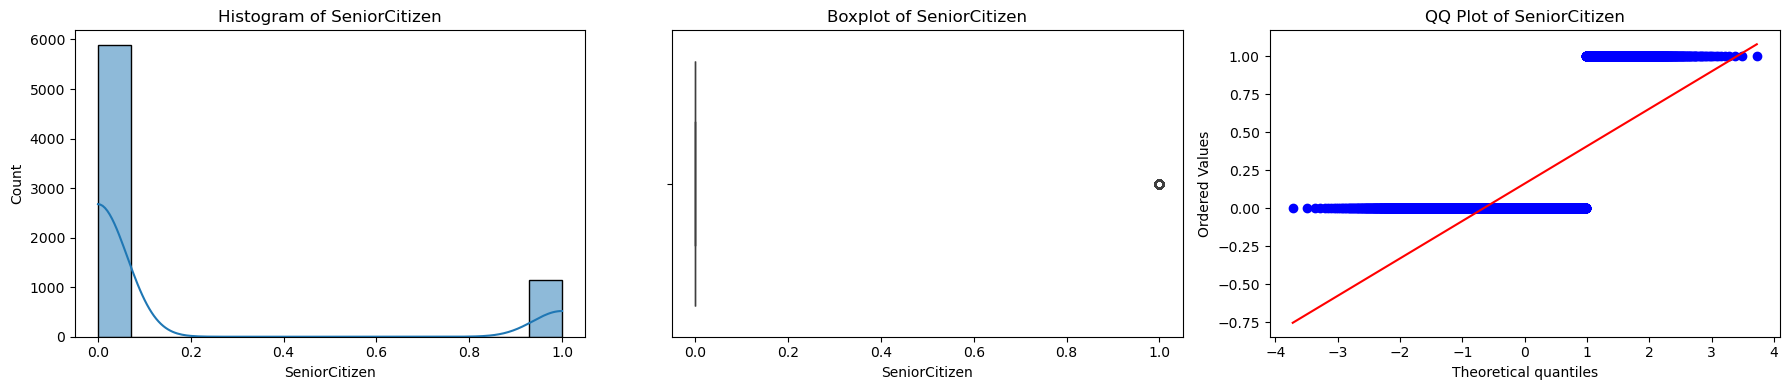

In [79]:
showHistBoxQQ("SeniorCitizen")

<div class="alert alert-info" role="alert">SeniorCitizen shows binary values with only 0s and 1s, so it should be converted into a categorical variable.</div>

### Tenure

Figure(1800x400)


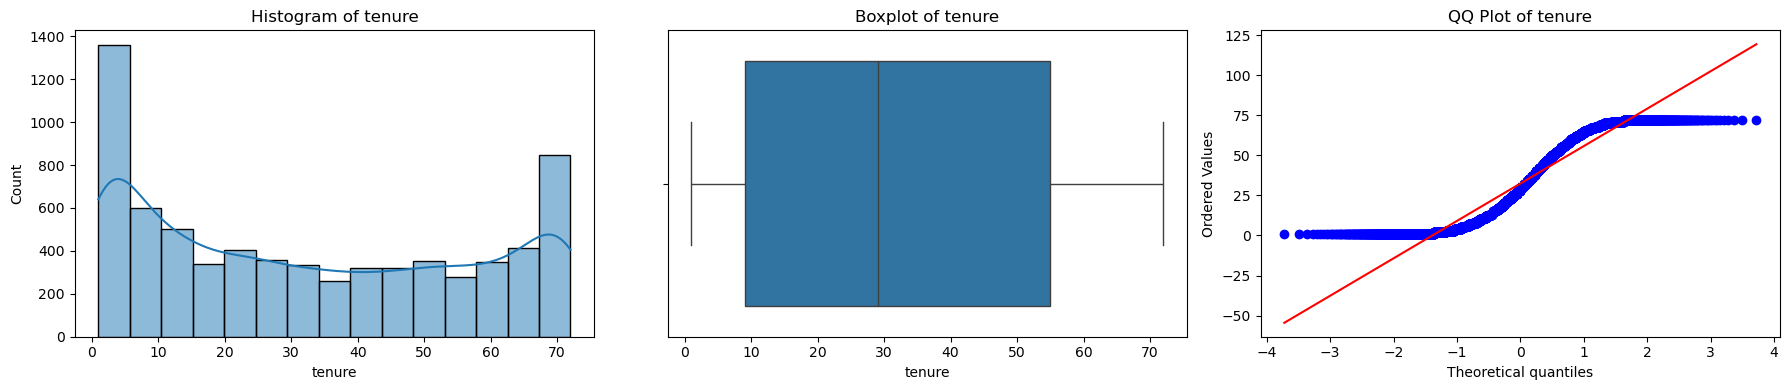

In [82]:
showHistBoxQQ("tenure")

<div class="alert alert-info" role="alert">tenure is right-skewed with a long tail of loyal customers, so applying a log transformation or binning into tenure groups, followed by scaling is appropriate.</div>

### MonthlyCharges

Figure(1800x400)


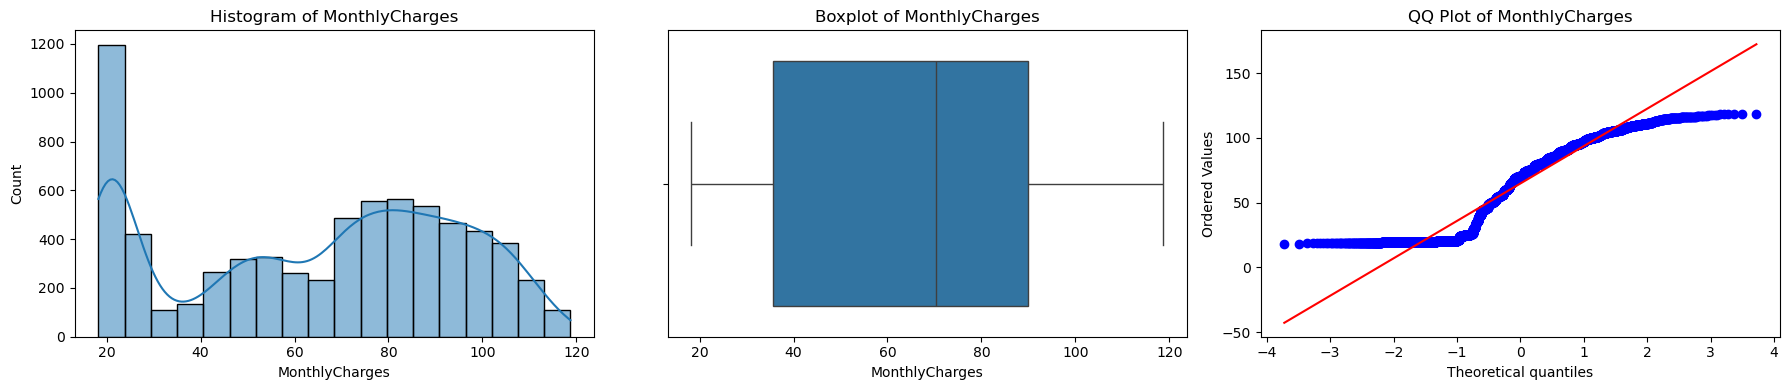

In [85]:
showHistBoxQQ("MonthlyCharges")

<div class="alert alert-info" role="alert">MonthlyCharges has a slightly bimodal distribution and moderate skew, so it should be scaled or binned into pricing tiers.</div>

### CLTV

Figure(1800x400)


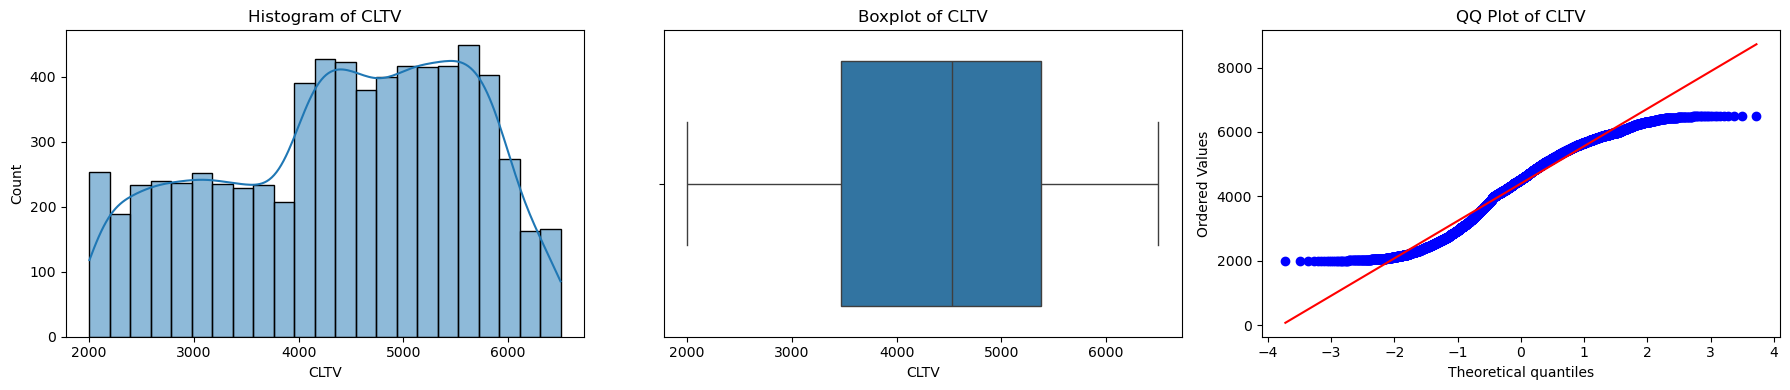

In [88]:
showHistBoxQQ("CLTV")

<div class="alert alert-info" role="alert">CLTV shows a wide spread and moderate skew, making it suitable for an optional log transformation, followed by scaling.</div>

### Satisfaction Score

Figure(1800x400)


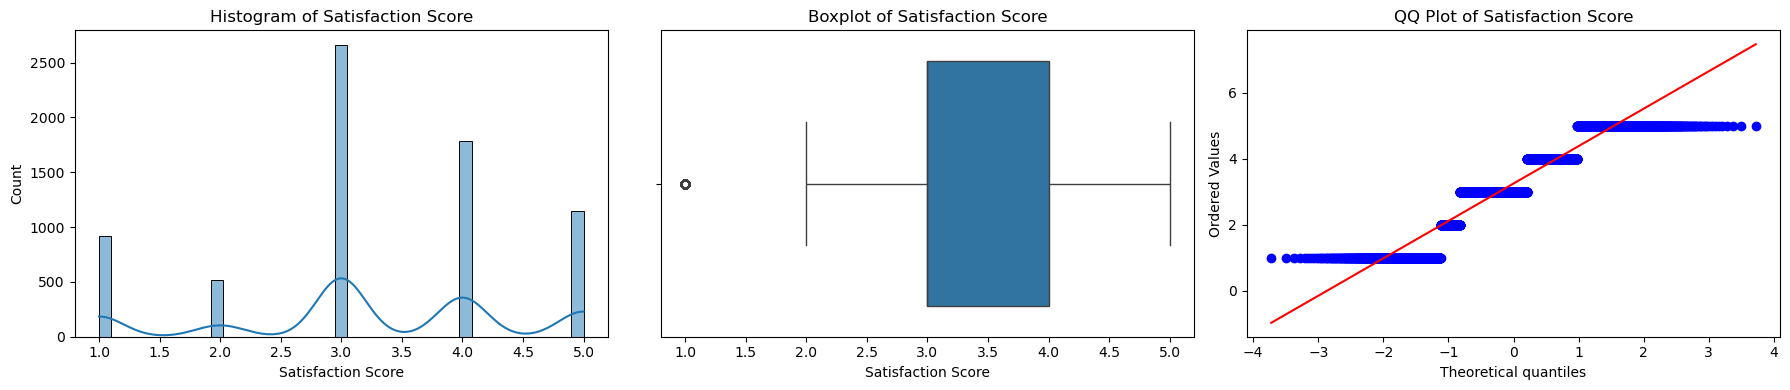

In [91]:
showHistBoxQQ("Satisfaction Score")

<div class="alert alert-info" role="alert">Satisfaction Score is clearly ordinal with values ranging from 1 to 5, so it should be encoded using an ordinal encoding scheme.</div>

**To do:**
1. `SeniorCitizen` → Binary (0/1), convert to **categorical**
1. `tenure` → Right-skewed; apply **log transform or bin**, then **scale**
1. `MonthlyCharges` → Slightly bimodal and skewed; **scale** or **bin into pricing tiers**
1. `CLTV` → Moderately skewed and spread out; optionally apply **log transform**, then **scale**
1. `Satisfaction Score` → Ordinal values (1–5); apply **ordinal encoding**

## Data Correlation (Nominal and Ratio scale correlation)

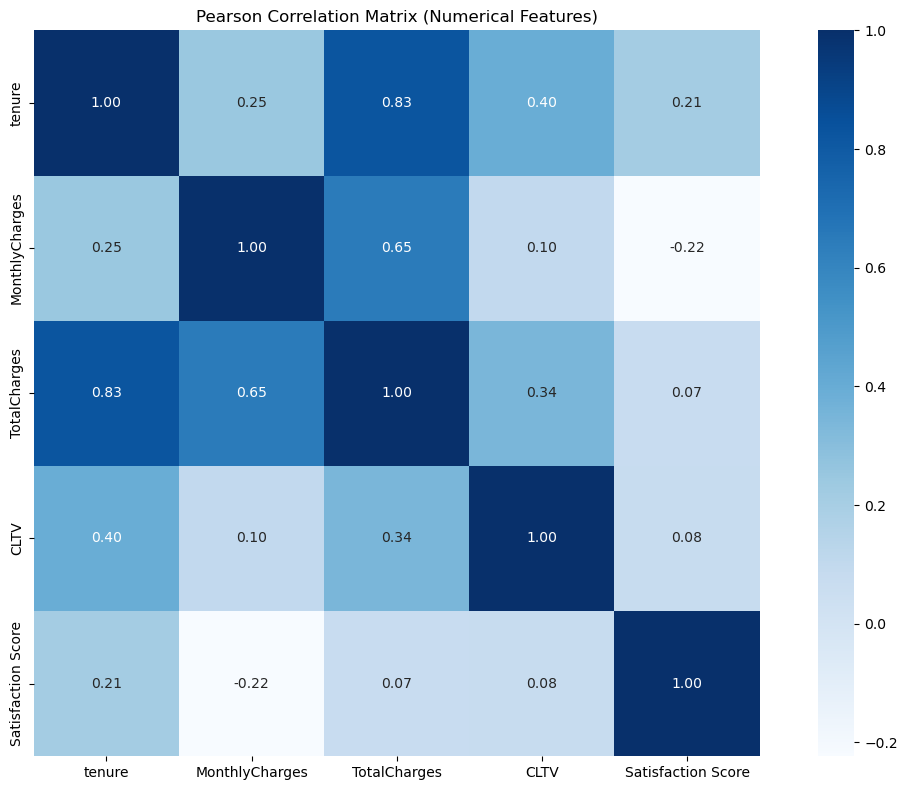

In [95]:
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()

# Compute Pearson correlation matrix
pearson_corr = df[numerical_features].corr(method="pearson")

# Plot the correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(pearson_corr, annot=True, cmap="Blues", fmt=".2f", square=True)
plt.title("Pearson Correlation Matrix (Numerical Features)")
plt.tight_layout()
plt.show()

**To do:**
1. `tenure` & `CLTV` → keep both; consider **feature interaction**
1. `MonthlyCharges` & `tenure` → keep both; **scale**
1. `SeniorCitizen` & `MonthlyCharges` → explore **interaction**
1. `Satisfaction Score` & `MonthlyCharges` → consider **feature interaction**
1. Most other correlations → **no action needed**

## Categorical Feature Distribution

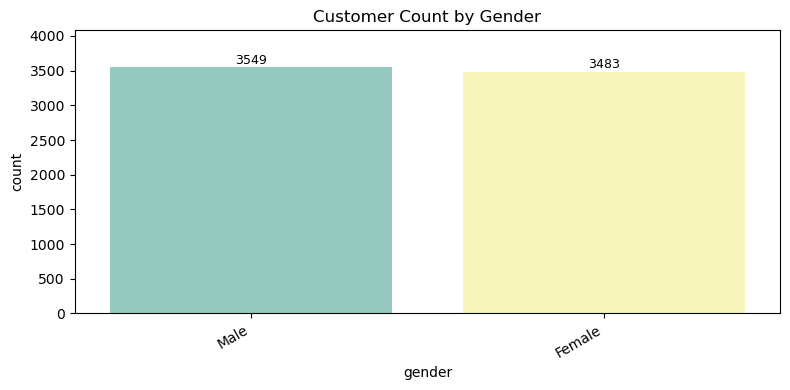

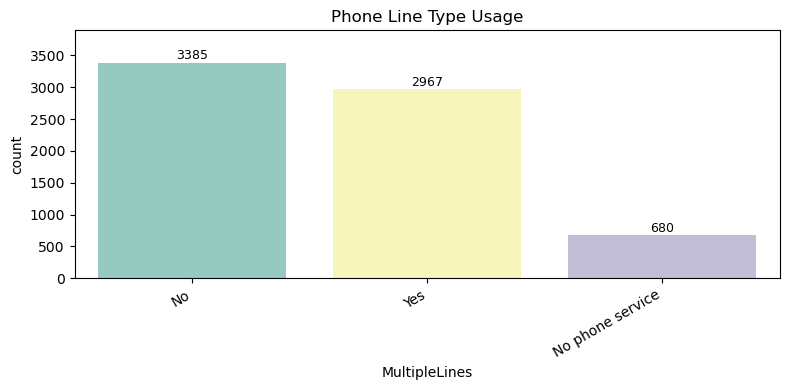

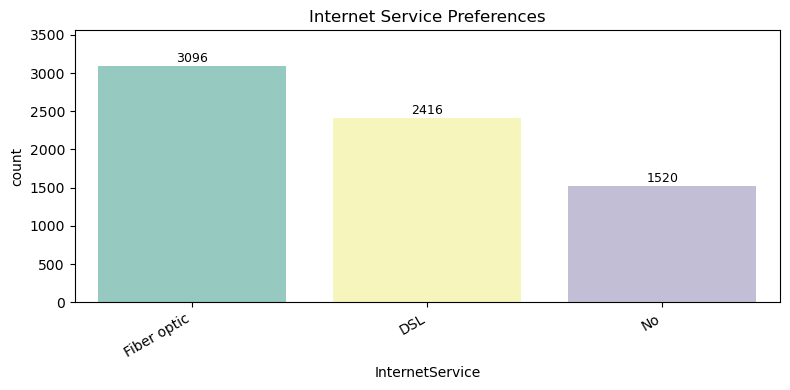

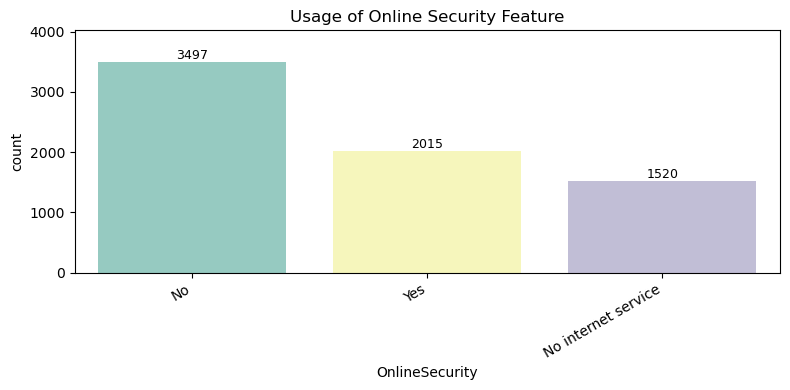

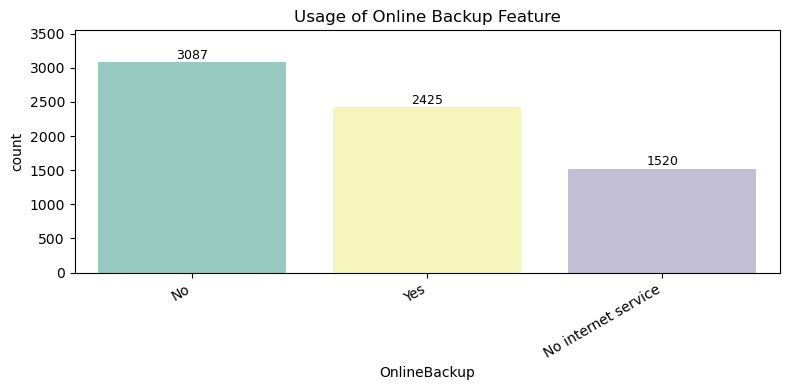

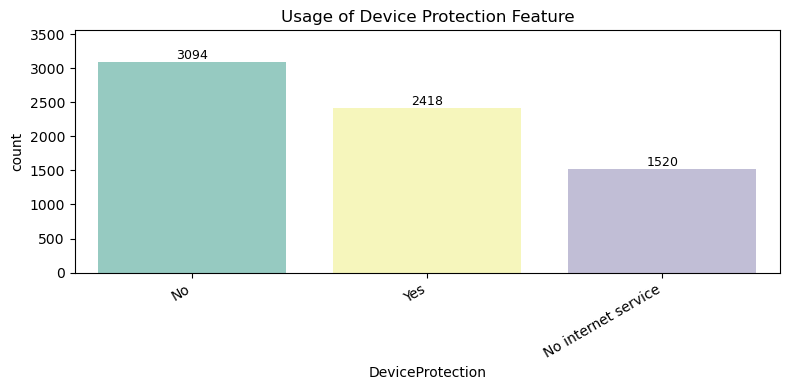

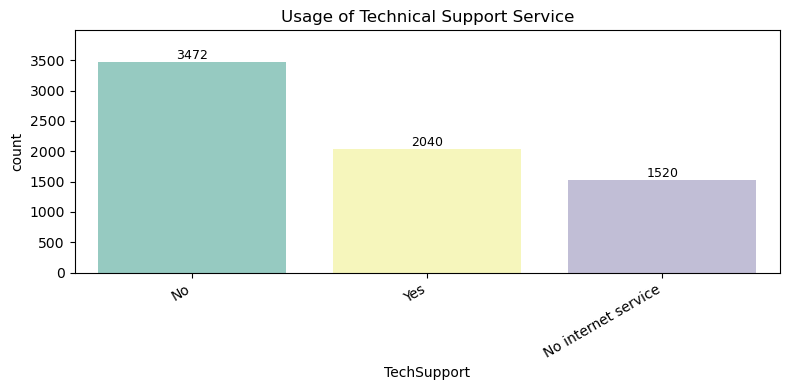

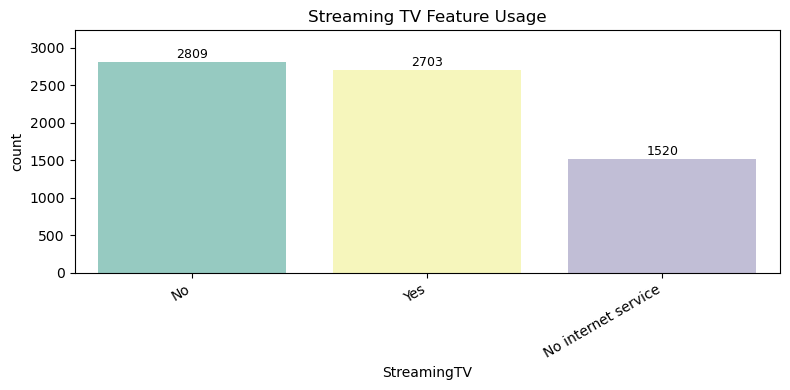

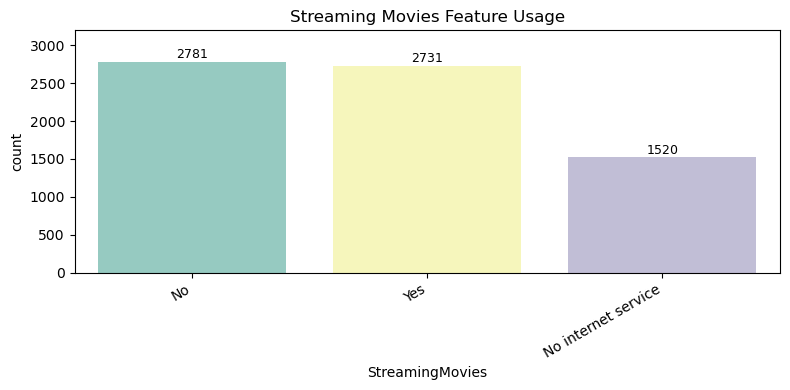

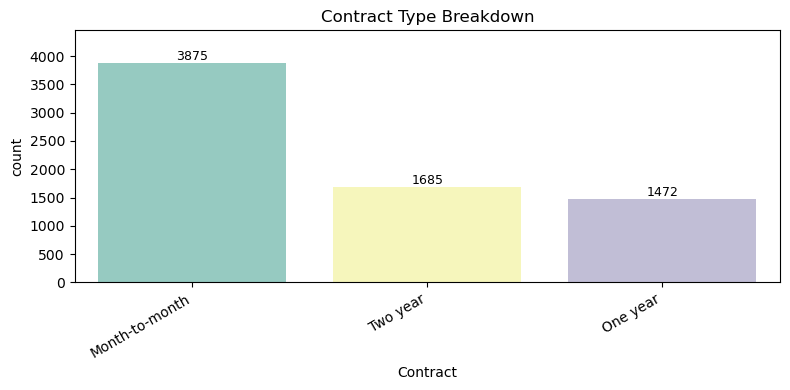

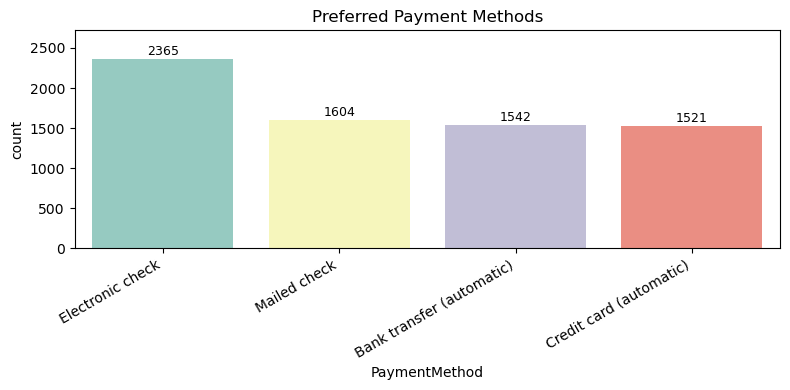

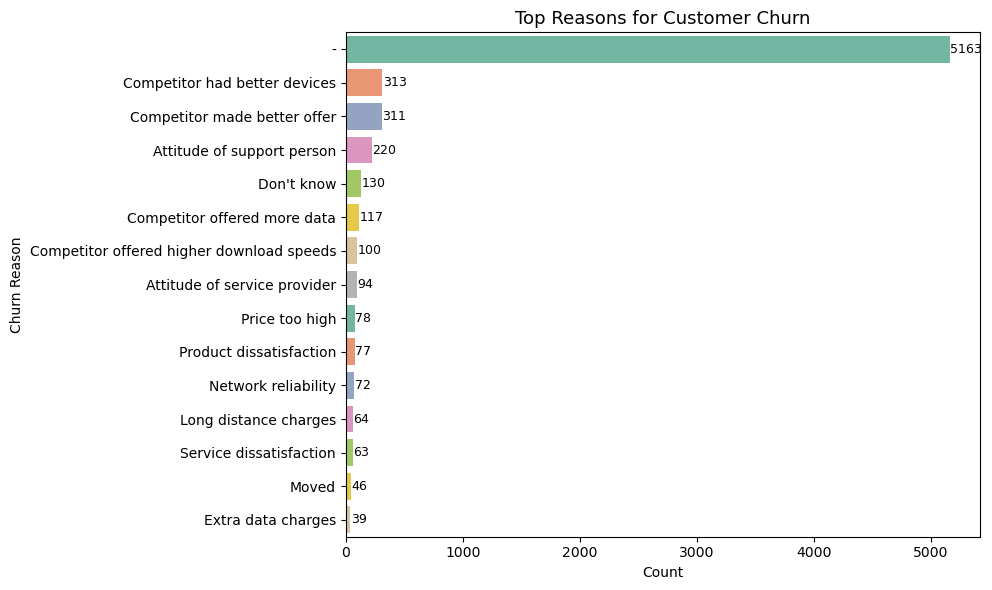

In [98]:
# List kolom kategorikal tanpa CustomerID
cat_cols = df.select_dtypes(include="object").columns
cat_cols = [col for col in cat_cols if col.lower() != "customerid"]

# Custom titles for better plot names
custom_titles = {
    "gender": "Customer Count by Gender",
    "MultipleLines": "Phone Line Type Usage",
    "InternetService": "Internet Service Preferences",
    "Contract": "Contract Type Breakdown",
    "PaymentMethod": "Preferred Payment Methods",
    "Churn Reason": "Top Reasons for Customer Churn",
    "OnlineSecurity": "Usage of Online Security Feature",
    "OnlineBackup": "Usage of Online Backup Feature",
    "DeviceProtection": "Usage of Device Protection Feature",
    "TechSupport": "Usage of Technical Support Service",
    "StreamingTV": "Streaming TV Feature Usage",
    "StreamingMovies": "Streaming Movies Feature Usage",
}

for col in cat_cols:
    try:
        df[col].astype(float)
        print(f"Skipping column {col} - looks numeric")
        continue
    except:
        pass

    unique_count = df[col].nunique()
    title = custom_titles.get(col, f"Distribution of {col}")

    if unique_count <= 10:
        # Low-cardinality: vertical barplot
        plt.figure(figsize=(8, 4))
        order = df[col].value_counts().index
        ax = sns.countplot(data=df, x=col, order=order, palette="Set3")

        max_height = 0
        for p in ax.patches:
            height = p.get_height()
            ax.text(
                p.get_x() + p.get_width() / 2.0,
                height + 50,
                f"{int(height)}",
                ha="center",
                fontsize=9,
            )
            max_height = max(max_height, height)

        ax.set_ylim(0, max_height * 1.15)
        plt.title(title, fontsize=12)
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.show()

    else:
        # High-cardinality: horizontal barplot
        top_n = 15
        top_counts = df[col].value_counts().nlargest(top_n)

        plt.figure(figsize=(10, 6))
        ax = sns.barplot(y=top_counts.index, x=top_counts.values, palette="Set2")

        for i, value in enumerate(top_counts.values):
            ax.text(value + 3, i, str(value), va="center", fontsize=9)

        plt.title(title, fontsize=13)
        plt.xlabel("Count")
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()

#### Insight
1. `Gender`

   The gender distribution is nearly balanced, suggesting gender has minimal direct influence on churn.
2. `Multiple Lines`

   Most customers do not have multiple phone lines, though a significant number do. This indicates a preference for single-line services among the majority.
3. `Internet Service & Add-on Features`

    - The majority of customers use **Fiber Optic internet**, followed by DSL; a smaller portion have no internet service.
    - Many customers do not subscribe to additional services such as **Online Security**, **Online Backup**, **Device Protection**, or **Tech Support**.
    - Approximately **1,520 customers** do not have internet service, and thus these additional services are marked as **"Unavailable"**
4. `Streaming Services`

   The use of **Streaming TV** and **Streaming Movies** is fairly balanced between users and non-users.
5. `Contract Type`

   The majority of customers are on **month-to-month contracts**, which are more flexible but associated with a higher likelihood of churn. Fewer customers are on **one-year** or **two-year contracts**.
6. `Payment Method`

   The most commonly used payment method is Electronic Check, followed by automatic payments via bank or credit card, and lastly mailed checks.
7. `City`

   The most commonly used payment method is Electronic Check, followed by automatic payments via bank or credit card, and lastly mailed checks.
8. `Churn Reason`
   - The most common churn reason is **"Unavailable"**, likely indicating **missing or unrecorded data**.
   - Other prominent reasons include competitive factors, such as better offers or devices provided by competitors

### Conclusion
The churn analysis indicates that customers on `month-to-month contracts` and those `not using additional services` (like Online Security or Tech Support) are more prone to churn. These customers often rely on `Fiber Optic internet`, prefer `electronic check payments`, and reside in `urban areas` such as **Los Angeles** and **San Diego**.

Additionally, a significant portion of churn reasons is marked as `“Unavailable”`, suggesting gaps in data collection, while many customers also leave due to **more attractive competitor offers or devices**.

To reduce churn, **retention strategies should focus on short-term contract users with minimal service engagement**, improve service bundling, and **enhance data quality** related to churn reasons for more targeted interventions.

### Distribution and Proportion of Key Churn-Related Features

### 1. Gender

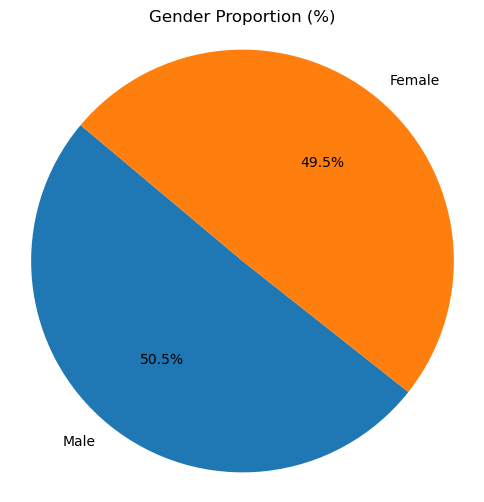

In [103]:
gender_prop = df["gender"].value_counts(normalize=True) * 100

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(gender_prop, labels=gender_prop.index, autopct="%1.1f%%", startangle=140)
plt.title("Gender Proportion (%)")
plt.axis("equal")
plt.show()

<div class="alert alert-info" role="alert">The gender proportion is nearly balanced, with female customers accounting for 49.5% and male for 50.5%</div>

### 2. Multiple Lines

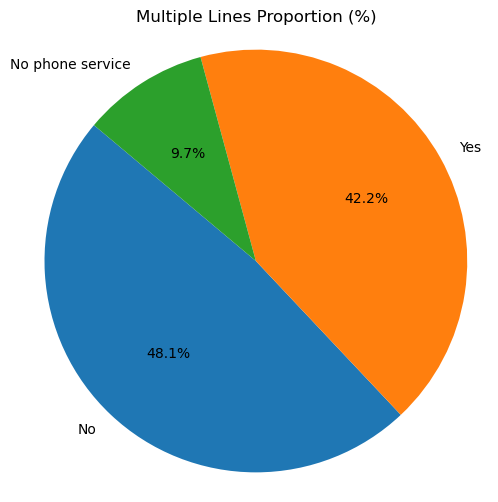

In [106]:
multiple_lines_prop = df["MultipleLines"].value_counts(normalize=True) * 100

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    multiple_lines_prop,
    labels=multiple_lines_prop.index,
    autopct="%1.1f%%",
    startangle=140,
)
plt.title("Multiple Lines Proportion (%)")
plt.axis("equal")
plt.show()

<div class="alert alert-info" role="alert">The majority chose "No," followed closely by "Yes," while "Unavailable" was the least selected option.</div>

### 3. Internet Service

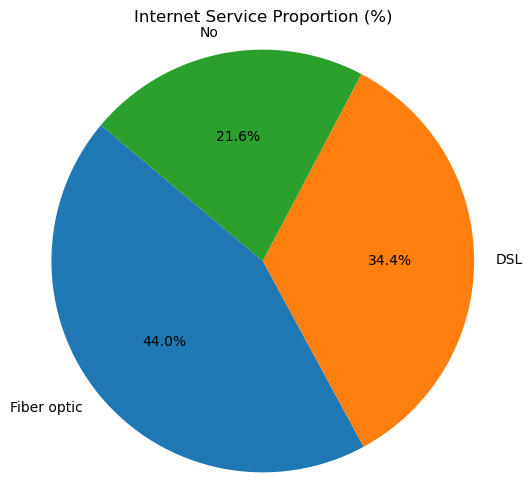

In [109]:
internet_service_prop = df["InternetService"].value_counts(normalize=True) * 100

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    internet_service_prop,
    labels=internet_service_prop.index,
    autopct="%1.1f%%",
    startangle=140,
)
plt.title("Internet Service Proportion (%)")
plt.axis("equal")
plt.show()

<div class="alert alert-info" role="alert">This indicates that fiber optic is the preferred choice for the majority of customers.</div>

- **Why Fiber Optic?**
  Likely due to its high-speed connectivity, which meets modern demands for streaming, gaming, and remote work.
- **Potential Action:**
  Companies could focus on promoting DSL upgrades to Fiber or investigate why 21.6% of customers have no internet service.

#### Insight
1. **Fiber Optic**
   - `Performance`: Faster speeds and reliability compared to DSL.
   - `Demand`: Rising needs for bandwidth-heavy activities (4K streaming, cloud services, WFH).
   - `Promotions`: Telecom companies may be aggressively marketing fiber plans.
2. **DSL**
   - `Availability`: Older infrastructure in certain areas.
   - `Cost`: Potentially cheaper for price-sensitive customers.
3. **No Internet**
   - `Demographic gaps`: Elderly or low-usage customers.
   - `Service gaps`: Rural/remote areas with limited coverage.
   - `Churn risk`: Customers may be using mobile data only.

#### Segmentation of InternetService by Age Group
In order to better understand customer behavior, we segmented the customers into three age groups: **Under 30**, **Middle Age (30–59)**, and **Senior (≥ 60)**.

This segmentation is based on commonly used demographic and marketing standards, where customers under 30 are typically classified as young adults, those aged 30–59 as middle-aged adults, and those aged 60 and above as seniors.

`According to the World Health Organization (WHO, 2020) and demographic studies by the OECD`, **age 60+ is often considered the threshold for older adults**, while **the age group 30–59 is widely recognized as the main working-age or middle-aged group**.

The visualization below shows the segmentation of InternetService types across these age groups, helping to highlight any differences in service preferences between younger, middle-aged, and older customers.

In [112]:
middle_age = df[(df["Under 30"] == 0) & (df["SeniorCitizen"] == 0)]
middle_age

,customerID,gender,Under 30,SeniorCitizen,Partner,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,tenure,MonthlyCharges,TotalCharges,CLTV,Satisfaction Score,Churn Reason,Churn
0,7590-VHVEG,Female,False,False,True,False,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,True,Electronic check,1,29.85,29.85,3964,3,-,False
1,5575-GNVDE,Male,False,False,False,True,No,DSL,Yes,No,Yes,No,No,No,One year,False,Mailed check,34,56.95,1889.50,3441,3,-,False
2,3668-QPYBK,Male,False,False,False,True,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,True,Mailed check,2,53.85,108.15,3239,1,Competitor made better offer,True
3,7795-CFOCW,Male,False,False,False,False,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,False,Bank transfer (automatic),45,42.30,1840.75,4307,3,-,False
5,9305-CDSKC,Female,False,False,False,True,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,True,Electronic check,8,99.65,820.50,5372,3,Moved,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7037,2569-WGERO,Female,False,False,False,True,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,True,Bank transfer (automatic),72,21.15,1419.40,5306,5,-,False
7038,6840-RESVB,Male,False,False,True,True,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,True,Mailed check,24,84.80,1990.50,2140,3,-,False
7039,2234-XADUH,Female,False,False,True,True,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,True,Credit card (automatic),72,103.20,7362.90,5560,4,-,False
7040,4801-JZAZL,Female,False,False,True,False,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,True,Electronic check,11,29.60,346.45,2793,4,-,False


AgeGroup
Middle Age (30–59)    4493
Under 30              1397
Senior (≥ 60)         1142
Name: count, dtype: int64


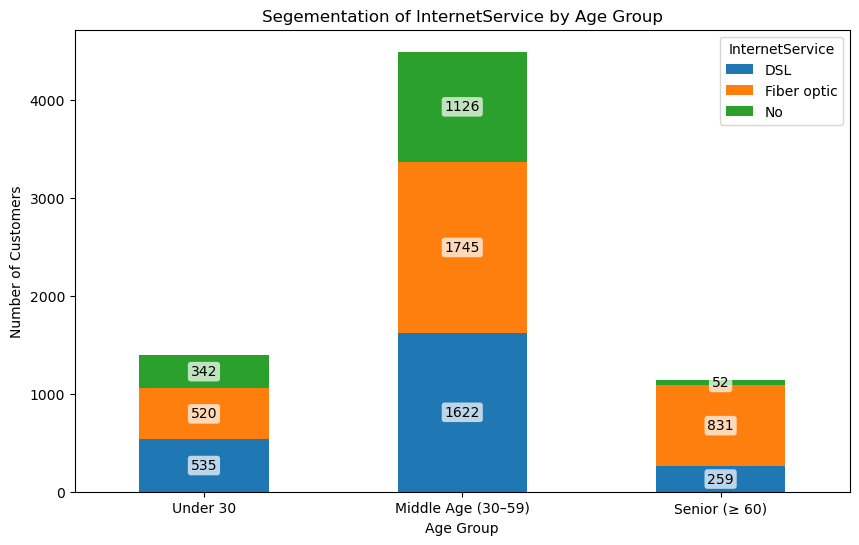

In [113]:
# Create AgeGroup column
df["AgeGroup"] = pd.NA
df.loc[df["Under 30"] == 1, "AgeGroup"] = "Under 30"
df.loc[(df["Under 30"] == 0) & (df["SeniorCitizen"] == 0), "AgeGroup"] = (
    "Middle Age (30–59)"
)
df.loc[df["SeniorCitizen"] == 1, "AgeGroup"] = "Senior (≥ 60)"

# Set AgeGroup as categorical with order
df["AgeGroup"] = pd.Categorical(
    df["AgeGroup"],
    categories=["Under 30", "Middle Age (30–59)", "Senior (≥ 60)"],
    ordered=True,
)

# Check the distribution
print(df["AgeGroup"].value_counts())

# Count InternetService in each AgeGroup
counts = df.groupby(["AgeGroup", "InternetService"]).size().reset_index(name="Count")

# Pivot for plotting
pivot_df = counts.pivot(
    index="AgeGroup", columns="InternetService", values="Count"
).fillna(0)

# Plot stacked barplot
ax = pivot_df.plot(kind="bar", figsize=(10, 6), stacked=True)

plt.title("Segementation of InternetService by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="InternetService")

# Add labels to each segment
for i, (idx, row) in enumerate(pivot_df.iterrows()):
    cumulative = 0
    for col in pivot_df.columns:
        count = row[col]
        if count > 0:
            y_pos = cumulative + count / 2
            # Jika count sangat kecil, tetap naikkan sedikit
            if count < 100:
                y_pos = cumulative + max(count / 2, 20)
            ax.text(
                x=i,
                y=y_pos,
                s=int(count),
                ha="center",
                va="center",
                fontsize=10,
                color="black",
                bbox=dict(
                    facecolor="white",
                    alpha=0.7,
                    edgecolor="none",
                    boxstyle="round,pad=0.2",
                ),
            )
            cumulative += count

plt.show()

<div class="alert alert-info" role="alert">The main target of internet services is the middle-aged group (30-59 years old)</div>

### 4. Add-on Features

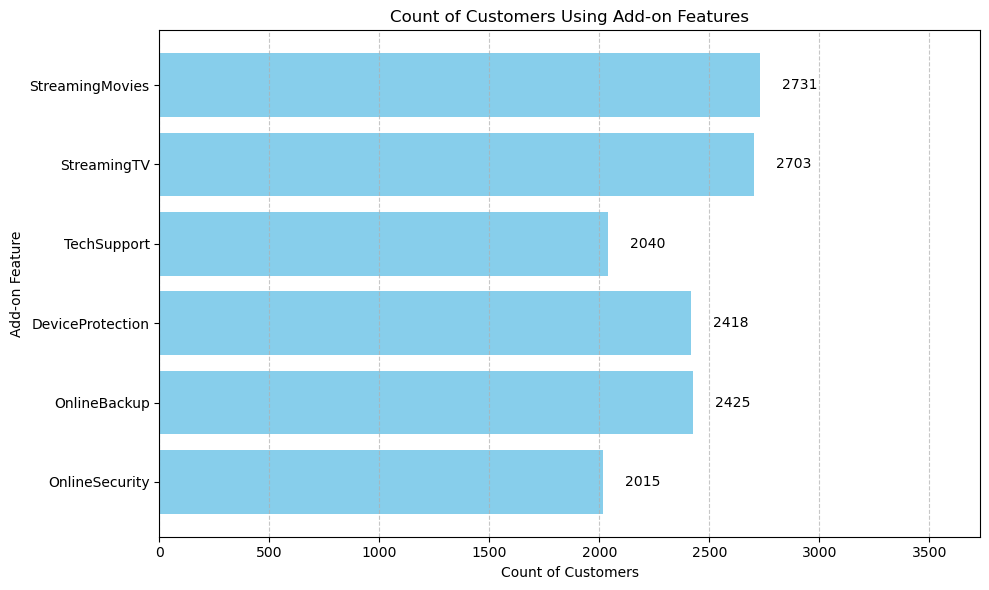

In [116]:
# List of add-on features
add_ons = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
]

# Count how many customers answered "Yes" for each add-on feature
yes_counts = df[add_ons].apply(lambda col: (col == "Yes").sum())

# Plot horizontal bar chart
plt.figure(figsize=(10, 6))
bars = plt.barh(yes_counts.index, yes_counts.values, color="skyblue")

# Add labels on each bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 100, bar.get_y() + bar.get_height() / 2, f"{int(width)}", va="center"
    )

# Chart formatting
plt.title("Count of Customers Using Add-on Features")
plt.xlabel("Count of Customers")
plt.ylabel("Add-on Feature")
plt.xlim(0, yes_counts.max() + 1000)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

### Key Insights & Recommendations

#### Insights
- **Streaming services (Movies/TV)** are the most popular features among customers.
- **Security/backup features** (DeviceProtection, OnlineBackup) show moderate usage, slightly lower than streaming.
- **OnlineSecurity and TechSupport** have the lowest adoption rates.

#### Recommendations
1. **Promote bundled packages** combining streaming with security features to increase value perception.
2. **Investigate low TechSupport adoption** - assess whether this is due to:
   - Already satisfactory service quality
   - Lack of awareness about the feature
   - Accessibility issues
3. **Create targeted campaigns** to boost security feature adoption among streaming users.

### 5. Contract Type

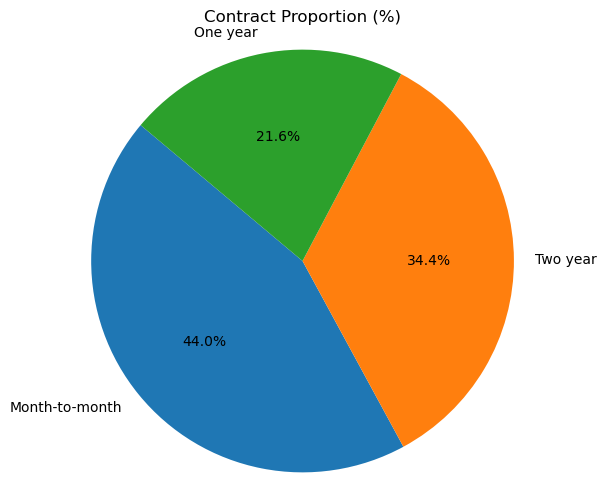

In [119]:
contract = df["Contract"].value_counts(normalize=True) * 100

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(internet_service_prop, labels=contract.index, autopct="%1.1f%%", startangle=140)
plt.title("Contract Proportion (%)")
plt.axis("equal")
plt.show()

<div class="alert alert-info" role="alert">The majority of customers are on month-to-month contracts (44.0%),  <strong>suggesting a preference for flexibility over long-term commitment</strong>. This behavior could impact revenue stability, as customers with short-term contracts are more likely to churn.</div>

#### Recommendations
To reduce churn and increase revenue stability, encourage customers on month-to-month contracts to switch to longer-term plans by offering targeted incentives such as:

- `Discounts` for 1-year or 2-year contract sign-ups
- `Loyalty rewards` for staying longer
- `Bundled services` that provide more value over time

This strategy can increase customer retention while balancing their need for flexibility

### 6. Payment Method

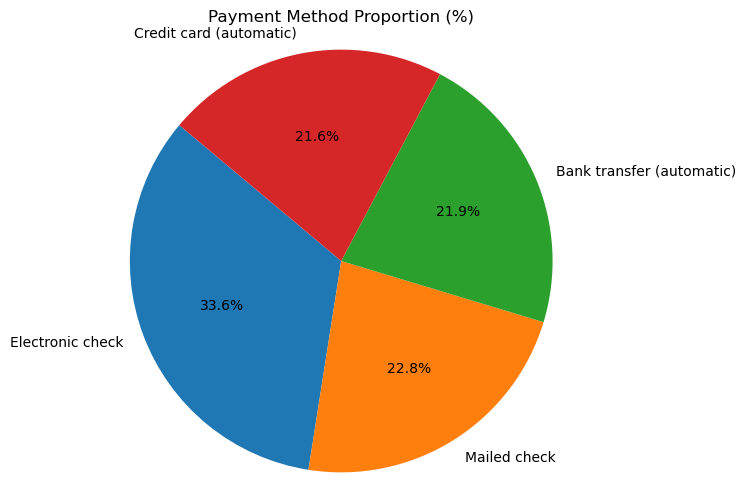

In [122]:
payment = df["PaymentMethod"].value_counts(normalize=True) * 100

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(payment, labels=payment.index, autopct="%1.1f%%", startangle=140)
plt.title("Payment Method Proportion (%)")
plt.axis("equal")
plt.show()

<div class="alert alert-info" role="alert">Customers strongly prefer digital payment methods (77.1% combined for automatic/electronic) over traditional mailed checks.</div>

#### Recommendation:
Promote and streamline digital or automatic payment methods to enhance customer convenience and reduce processing delays. Consider:

- Offering discounts or loyalty points for customers who switch from manual to automatic payments
- Providing in-app or online tutorials to help older or less tech-savvy users transition
- Reducing reliance on manual methods (e.g., mailed checks) to lower operational costs

### Breakdown of Why Customers Leave

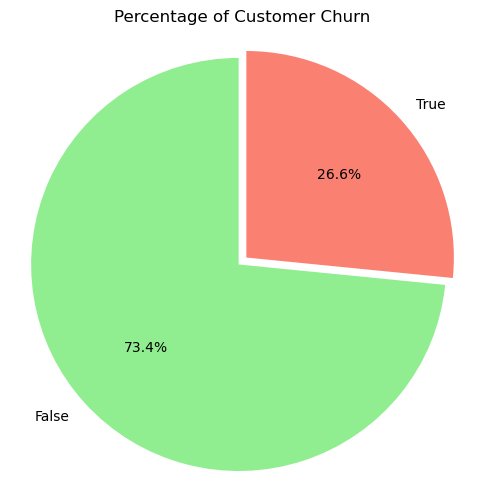

In [125]:
# Pie chart
churn_percentage = df["Churn"].value_counts(normalize=True) * 100
labels = churn_percentage.index
colors = ["lightgreen", "salmon"]

plt.figure(figsize=(6, 6))
plt.pie(
    churn_percentage,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    explode=(0, 0.05),
)
plt.title("Percentage of Customer Churn")
plt.axis("equal")
plt.show()

<div class="alert alert-info" role="alert">26.6% of customers churned, while 73.4% remained active, highlighting a significant retention opportunity.<div></div>

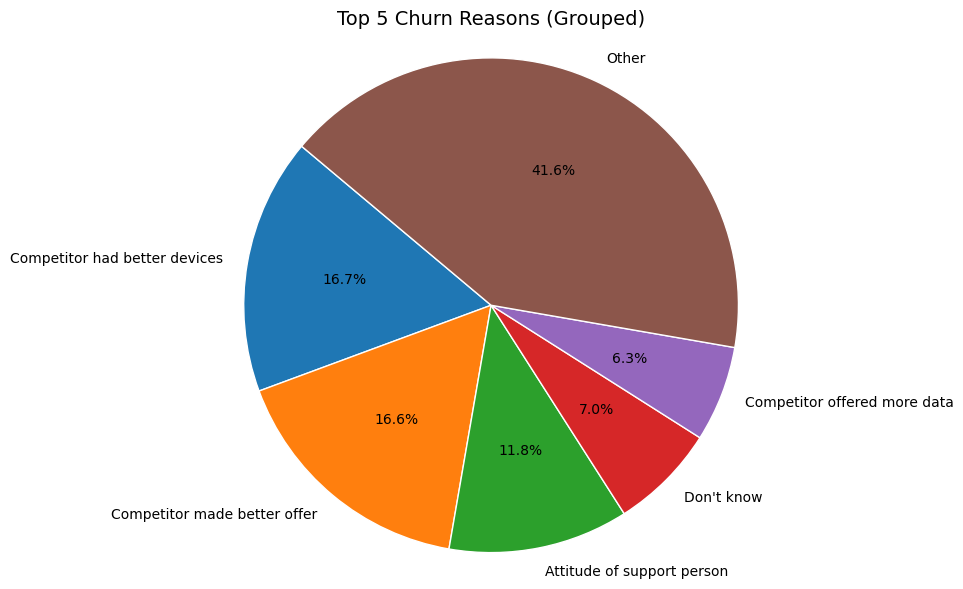

In [127]:
# Filter churn customers
churn_df = df[df["Churn"] == True]

# Calculate the proportion of churn reason
reason_prop = churn_df["Churn Reason"].value_counts(normalize=True) * 100

# Show only the top 5 reasons, combine the rest into “Other”
top_n = 5
top_reasons = reason_prop[:top_n]
other_sum = reason_prop[top_n:].sum()

# Combine “Other” if there are any remaining categories
if other_sum > 0:
    top_reasons["Other"] = other_sum

# Pie chart
plt.figure(figsize=(8, 6))
plt.pie(
    top_reasons,
    labels=top_reasons.index,
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops={"linewidth": 1, "edgecolor": "white"},
)
plt.title("Top 5 Churn Reasons (Grouped)", fontsize=14)
plt.axis("equal")
plt.tight_layout()
plt.show()

<div class="alert alert-info" role="alert">Most customers churned due to other reasons, while the rest were driven by better competitor offers, devices, and poor support staff attitude.</div>

### Focused Recommendations: Competitor & Support Attitude
1. `Benchmark competitor offerings` — regularly track their pricing, data packages, and devices, then adjust your positioning to match or beat their strengths.
2. `Increase product value` through compelling bundles, device financing, or exclusive perks that competitors can’t easily replicate.
3. `Reinforce loyalty programs` to retain customers even when competitors offer short-term deals.
4. `Retrain support staff` with a focus on empathy, response time, and issue resolution — a poor service experience can drive churn even if the product is solid.
5. `Continuously monitor service satisfaction` (e.g., through CSAT or NPS) to ensure support attitude isn’t a hidden churn driver.

---

# Split Data
---

In [131]:
df = df[
    [
        "gender",
        "AgeGroup",
        "Partner",
        "CLTV",
        "PhoneService",
        "MultipleLines",
        "InternetService",
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies",
        "PaperlessBilling",
        "PaymentMethod",
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Contract",
        "Churn Reason",
        "Churn",
    ]
]

In [132]:
train, test = train_test_split(df, test_size=0.2, stratify=df["Churn"], random_state=42)

<div class="alert alert-info" role="alert">Split train test 80% with train_test_split.<div></div>

In [134]:
train

,gender,AgeGroup,Partner,CLTV,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,PaymentMethod,tenure,MonthlyCharges,TotalCharges,Contract,Churn Reason,Churn
1413,Male,Middle Age (30–59),True,4603,True,Yes,Fiber optic,Yes,Yes,Yes,Yes,No,No,False,Credit card (automatic),65,94.55,6078.75,Two year,-,False
7003,Male,Under 30,False,2734,False,No phone service,DSL,No,No,Yes,Yes,No,No,False,Electronic check,26,35.75,1022.50,Month-to-month,-,False
3355,Female,Under 30,True,4095,True,Yes,Fiber optic,No,Yes,Yes,Yes,No,No,False,Credit card (automatic),68,90.20,6297.65,Two year,-,False
4494,Male,Middle Age (30–59),False,5828,True,No,Fiber optic,No,Yes,No,No,No,Yes,False,Electronic check,3,84.30,235.05,Month-to-month,-,False
3541,Female,Middle Age (30–59),True,5565,False,No phone service,DSL,Yes,No,No,No,Yes,No,False,Bank transfer (automatic),49,40.65,2070.75,Month-to-month,-,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3451,Male,Senior (≥ 60),True,4871,True,No,Fiber optic,No,No,No,No,No,No,True,Bank transfer (automatic),65,70.95,4555.20,One year,-,False
5123,Female,Senior (≥ 60),False,4526,True,No,Fiber optic,No,Yes,No,No,No,No,True,Credit card (automatic),15,75.30,1147.45,Month-to-month,Competitor offered more data,True
4135,Female,Under 30,True,3570,True,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,True,Credit card (automatic),36,92.90,3379.25,Two year,-,False
4249,Female,Middle Age (30–59),True,5289,True,No,DSL,No,Yes,Yes,No,No,Yes,True,Mailed check,10,65.90,660.05,One year,-,False


In [135]:
test

,gender,AgeGroup,Partner,CLTV,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,PaymentMethod,tenure,MonthlyCharges,TotalCharges,Contract,Churn Reason,Churn
974,Female,Middle Age (30–59),True,5446,True,No,DSL,No,Yes,No,Yes,Yes,Yes,True,Credit card (automatic),59,75.95,4542.35,Two year,-,False
619,Female,Middle Age (30–59),False,4025,True,Yes,Fiber optic,No,Yes,No,No,No,No,True,Bank transfer (automatic),7,78.55,522.95,Month-to-month,-,False
4289,Female,Middle Age (30–59),False,5755,True,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,False,Mailed check,54,20.10,1079.45,Two year,-,False
3721,Female,Middle Age (30–59),False,3845,True,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,False,Mailed check,2,20.65,38.70,Month-to-month,Attitude of support person,True
4533,Female,Middle Age (30–59),True,5707,True,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,True,Bank transfer (automatic),71,105.15,7555.00,Two year,-,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4829,Female,Middle Age (30–59),False,4998,True,No,DSL,No,No,No,No,No,No,True,Bank transfer (automatic),12,45.00,524.35,Month-to-month,-,False
5176,Female,Middle Age (30–59),False,3287,False,No phone service,DSL,Yes,No,No,Yes,No,Yes,False,Mailed check,26,45.80,1147.00,Month-to-month,-,False
2750,Male,Middle Age (30–59),False,2787,True,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,True,Mailed check,3,19.45,69.25,One year,-,False
4432,Male,Under 30,False,4050,False,No phone service,DSL,Yes,Yes,No,Yes,No,No,True,Mailed check,37,40.55,1390.85,Two year,-,False


In [136]:
# Save data set
# train.to_csv("Dataset/train_telco.csv", index=False)
# test.to_csv("Dataset/test_telco.csv", index=False)

Di comment biar ga berubah csvnya

---

# Methodology (Data Analytics)
---

<div class="alert alert-info" role="alert">Train Telco Customer Churn Data set.</div>

In [211]:
df = pd.read_csv("Dataset/train_telco.csv")
df.sample(5)

,gender,AgeGroup,Partner,CLTV,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,PaymentMethod,tenure,MonthlyCharges,TotalCharges,Contract,Churn Reason,Churn
3366,Female,Under 30,True,6489,True,No,DSL,Yes,Yes,Yes,No,Yes,No,True,Credit card (automatic),62,72.00,4284.20,Two year,-,False
3815,Female,Under 30,False,4624,False,No phone service,DSL,Yes,Yes,No,Yes,No,No,True,Mailed check,18,40.20,711.95,One year,-,False
588,Male,Senior (≥ 60),True,2927,False,No phone service,DSL,Yes,No,No,No,No,No,False,Credit card (automatic),27,30.75,805.10,Month-to-month,Competitor made better offer,True
3930,Female,Middle Age (30–59),True,5756,True,No,DSL,Yes,No,No,No,No,No,True,Mailed check,5,49.40,232.55,Month-to-month,-,False
3370,Female,Under 30,False,4479,True,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,False,Bank transfer (automatic),7,20.00,137.60,Month-to-month,Attitude of support person,True


## Analysis Paradigm

### Descriptive Analysis

### Inferential Analysis

## Analysis Structure

## Expected Analysis Results

---

# Methodology (Machine Learning)
---

In [159]:
# Train Telco Customer Churn Data set
# df = pd.read_csv("Dataset/train_telco.csv")
# df.sample(5)

---